# Student Performance Dataset Analysis


# 1. Import libraries


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 


# 2. Load dataset

In [6]:
df=pd.read_csv("student-mat.csv",sep=";")

# 3. Explore dataset

In [7]:
print("First 5 rows")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

First 5 rows
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Dataset Shape:
(395, 33)

Column Names:
Index(['school', 'sex', 'age', 'ad

# 4. Check missing values

In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


# 5. Remove duplicates

In [12]:
df=df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


Shape after removing duplicates:
(395, 33)


# 6. Basic information

In [13]:
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    

# Analysis Questions

# 1. Average final grade G3

In [16]:
average_g3 = df["G3"].mean()
print("\nAverage Final Grade (G3):", round(average_g3, 1))


Average Final Grade (G3): 10.4


# 2. How many students scored above 15?

In [17]:
students_above_15 = df[df["G3"] > 15].shape[0]
print("Number of students scored above 15:", students_above_15)

Number of students scored above 15: 40


# 3. Is study time correlated with performance?

In [21]:
correlation = df["studytime"].corr(df["G3"])
print("Correlation between study time and final grade:", round(correlation, 2))

if correlation > 0:
    print("Study time has a positive correlation with performance.")
elif correlation < 0:
    print("Study time has a negative correlation with performance.")
else:
    print("No correlation between study time and performance.")

Correlation between study time and final grade: 0.1
Study time has a positive correlation with performance.


# 4. Which gender performs better on average?

In [22]:
gender_avg = df.groupby("sex")["G3"].mean()
print("\nAverage Final Grade by Gender:")
print(gender_avg)

better_gender = gender_avg.idxmax()
print("Better performing gender on average:", better_gender)


Average Final Grade by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64
Better performing gender on average: M


# Visualizations

# 1. Histogram of grades

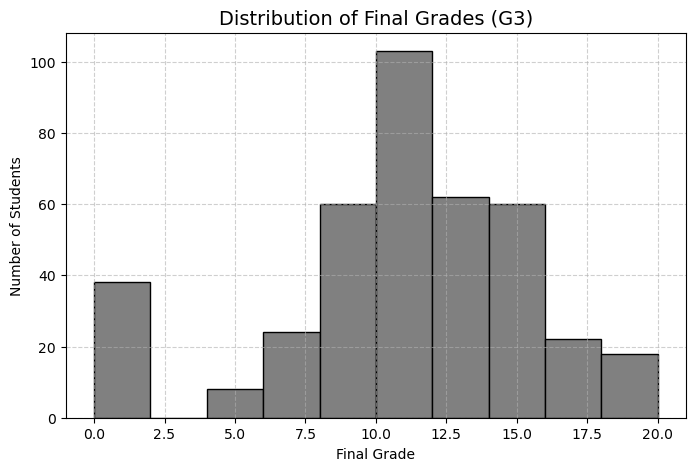

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["G3"],
         bins=10,
         color="grey",
         edgecolor="black")

plt.title("Distribution of Final Grades (G3)", fontsize=14)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Scatterplot: study time vs grades

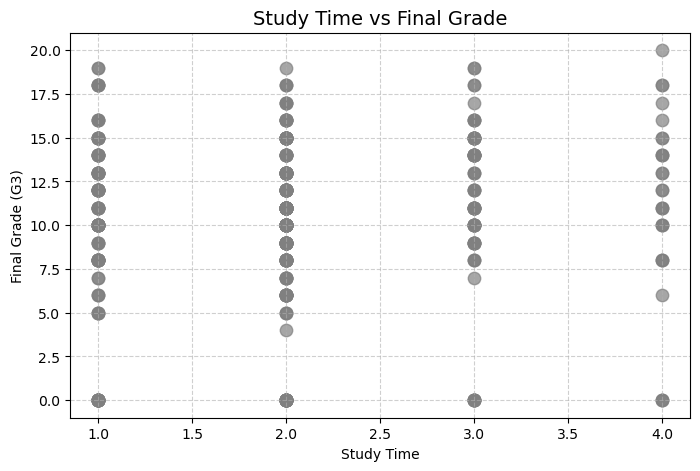

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(df["studytime"],
            df["G3"],
            color="grey",
            s=80,
            alpha=0.7)

plt.title("Study Time vs Final Grade", fontsize=14)
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Bar chart: male vs female average score

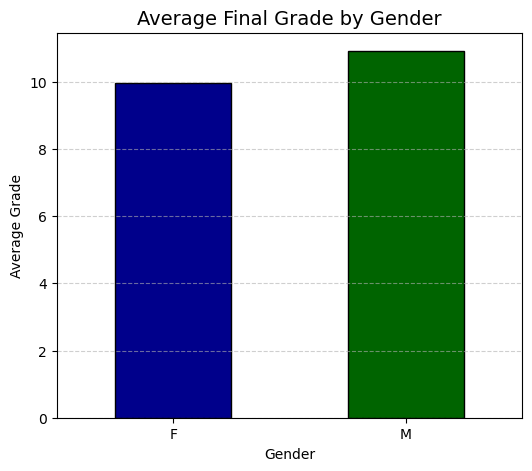

In [39]:
gender_avg = df.groupby("sex")["G3"].mean()

plt.figure(figsize=(6,5))
gender_avg.plot(kind="bar",
                color=["darkblue", "darkgreen"],
                edgecolor="black")

plt.title("Average Final Grade by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Average Grade")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Conclusion

In [40]:
print("\nConclusion:")
print("1. The average final grade of students is", round(average_g3, 2))
print("2. Total students scoring above 15 are", students_above_15)
print("3. Correlation between study time and performance is", round(correlation, 2))
print("4. Gender", better_gender, "performs better on average.")


Conclusion:
1. The average final grade of students is 10.42
2. Total students scoring above 15 are 40
3. Correlation between study time and performance is 0.1
4. Gender M performs better on average.
